# 🤖 MACHINE LEARNING - CLUSTERING E CLASSIFICAÇÃO
## Impacto da Presença Digital em Hotéis Brasileiros

---

**Dataset:** 9.566 hotéis brasileiros (após filtro totalScore > 0.2)  
**Objetivo:** Clustering (não-supervisionado) + Classificação (supervisionado)  

---

### Estrutura:
**PARTE 1 - CLUSTERING (Não-Supervisionado):**
1. K-Means
2. Hierarchical Clustering
3. Expectation-Maximization (EM - Gaussian Mixture)
4. DBSCAN

**PARTE 2 - CLASSIFICAÇÃO (Supervisionado):**
1. Árvore de Decisão
2. Random Forest
3. KNN (K-Nearest Neighbors)
4. Rede Neural

**Target:** `has_website` (0=SEM, 1=COM)  
**Features:** `totalScore`, `reviewsCount`

## 1️⃣ SETUP

In [1]:
# Instalar dependências
!pip install pandas numpy matplotlib seaborn scikit-learn scipy openpyxl -q
print("✅ Bibliotecas instaladas!")

✅ Bibliotecas instaladas!


In [2]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    accuracy_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import euclidean, cityblock
import warnings
warnings.filterwarnings('ignore')

# Config visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100

print("✅ Importações concluídas!")

✅ Importações concluídas!


## 2️⃣ CARREGAR DADOS

In [3]:
# Carregar dataset
file_path = 'data-hoteis-atualizado.xlsx'
df = pd.read_excel(file_path)

# Converter has_website se necessário
if df['has_website'].dtype == 'object':
    df['has_website'] = df['has_website'].map({'SEM': 0, 'COM': 1})

# Filtrar outliers (mesmo filtro da Entrega 2)
df_filtrado = df[df['totalScore'] > 0.2].copy()

print(f"✅ Dataset: {len(df_filtrado):,} hotéis")
print(f"   COM: {(df_filtrado['has_website']==1).sum():,}")
print(f"   SEM: {(df_filtrado['has_website']==0).sum():,}")

✅ Dataset: 9,561 hotéis
   COM: 4,849
   SEM: 4,712


In [4]:
# Preparar features (X) e target (y)
X = df_filtrado[['totalScore', 'reviewsCount']].values
y = df_filtrado['has_website'].values

# Normalizar features (importante para clustering e NN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Features preparadas:")
print(f"   X: {X.shape}")
print(f"   y: {y.shape}")
print(f"   X_scaled (normalizado): {X_scaled.shape}")

✅ Features preparadas:
   X: (9561, 2)
   y: (9561,)
   X_scaled (normalizado): (9561, 2)


---
# PARTE 1: CLUSTERING (NÃO-SUPERVISIONADO)
---

## 3️⃣ MÉTODO 1: K-MEANS

In [5]:
# Testar diferentes valores de K (2 a 5 clusters)
resultados_kmeans = []

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Métricas
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    inertia = kmeans.inertia_

    resultados_kmeans.append({
        'K': k,
        'Silhouette': silhouette,
        'Davies-Bouldin': davies_bouldin,
        'Inertia': inertia,
        'labels': labels
    })

df_kmeans = pd.DataFrame(resultados_kmeans)
print("="*60)
print("K-MEANS - Resultados")
print("="*60)
print(df_kmeans[['K', 'Silhouette', 'Davies-Bouldin', 'Inertia']].to_string(index=False))
print("\n💡 Melhor K: Maior Silhouette ou Menor Davies-Bouldin")

# Melhor K
melhor_k = df_kmeans.loc[df_kmeans['Silhouette'].idxmax(), 'K']
print(f"🏆 Melhor K: {melhor_k}")

# Usar melhor K
kmeans_final = KMeans(n_clusters=int(melhor_k), random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

K-MEANS - Resultados
 K  Silhouette  Davies-Bouldin      Inertia
 2    0.437060        0.881073 13489.429314
 3    0.497846        0.696350  8636.317525
 4    0.511455        0.646102  6558.181294
 5    0.481284        0.643257  4771.789612

💡 Melhor K: Maior Silhouette ou Menor Davies-Bouldin
🏆 Melhor K: 4


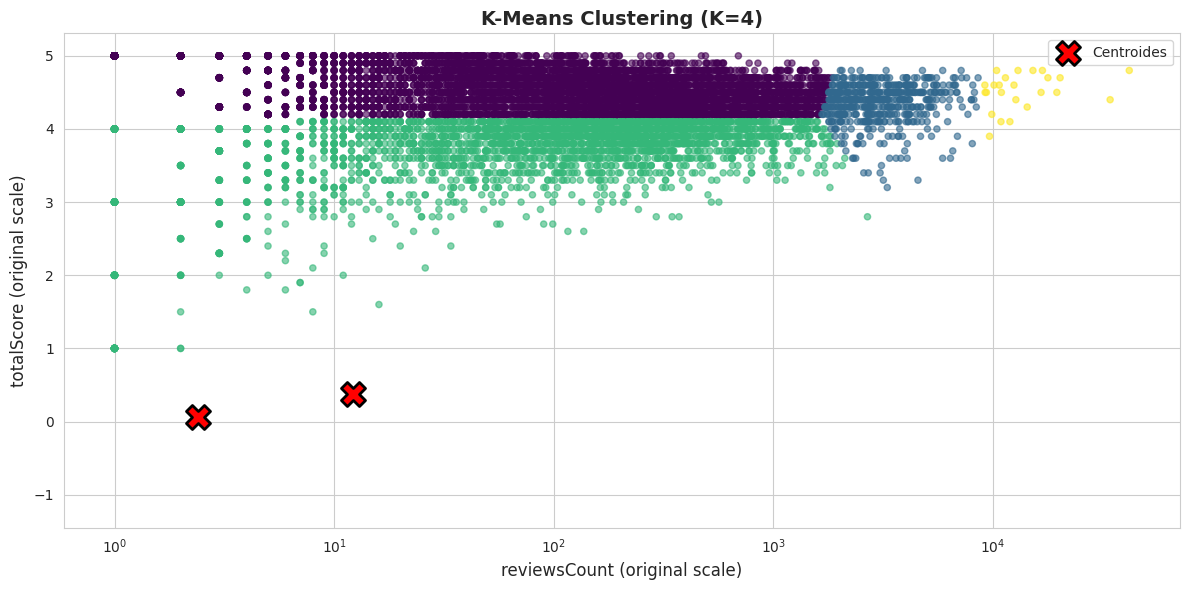

In [6]:
# Gráfico K-Means
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 1], X[:, 0], c=labels_kmeans, cmap='viridis', alpha=0.6, s=20)
plt.scatter(kmeans_final.cluster_centers_[:, 1], kmeans_final.cluster_centers_[:, 0],
            c='red', marker='X', s=300, edgecolor='black', linewidth=2, label='Centroides')
plt.xlabel('reviewsCount (original scale)', fontsize=12)
plt.ylabel('totalScore (original scale)', fontsize=12)
plt.title(f'K-Means Clustering (K={int(melhor_k)})', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('clustering_kmeans.png', dpi=300)
plt.show()

## 4️⃣ MÉTODO 2: HIERARCHICAL CLUSTERING

In [7]:
# Hierarchical Clustering (Agglomerative)
resultados_hierarchical = []

for k in range(2, 6):
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hierarchical.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)

    resultados_hierarchical.append({
        'K': k,
        'Silhouette': silhouette,
        'Davies-Bouldin': davies_bouldin,
        'labels': labels
    })

df_hierarchical = pd.DataFrame(resultados_hierarchical)
print("="*60)
print("HIERARCHICAL CLUSTERING - Resultados")
print("="*60)
print(df_hierarchical[['K', 'Silhouette', 'Davies-Bouldin']].to_string(index=False))

melhor_k_hier = df_hierarchical.loc[df_hierarchical['Silhouette'].idxmax(), 'K']
print(f"🏆 Melhor K: {melhor_k_hier}")

hierarchical_final = AgglomerativeClustering(n_clusters=int(melhor_k_hier), linkage='ward')
labels_hierarchical = hierarchical_final.fit_predict(X_scaled)

HIERARCHICAL CLUSTERING - Resultados
 K  Silhouette  Davies-Bouldin
 2    0.678643        0.685730
 3    0.393673        0.706605
 4    0.426832        0.671391
 5    0.430611        0.633121
🏆 Melhor K: 2


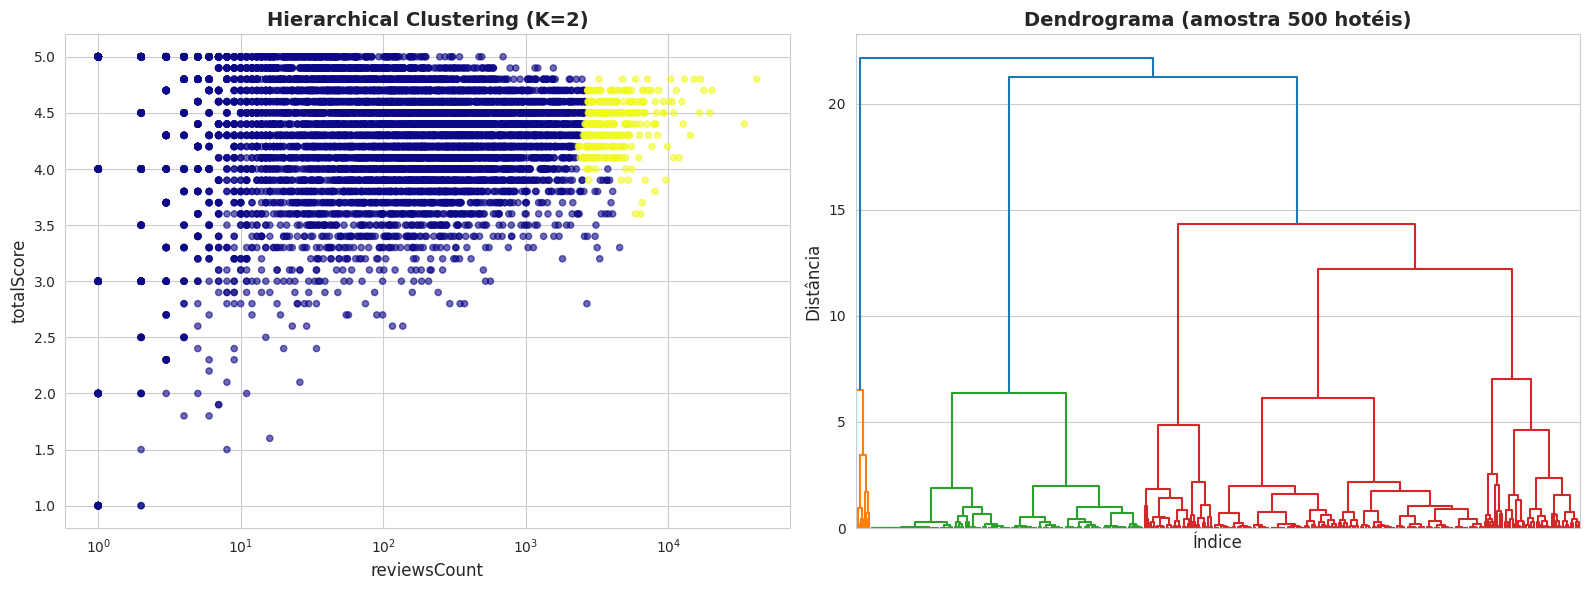

In [8]:
# Gráfico Hierarchical + Dendrograma
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(X[:, 1], X[:, 0], c=labels_hierarchical, cmap='plasma', alpha=0.6, s=20)
axes[0].set_xlabel('reviewsCount', fontsize=12)
axes[0].set_ylabel('totalScore', fontsize=12)
axes[0].set_title(f'Hierarchical Clustering (K={int(melhor_k_hier)})', fontsize=14, fontweight='bold')
axes[0].set_xscale('log')

# Dendrograma (sample de 500 pontos para não travar)
sample_idx = np.random.choice(len(X_scaled), 500, replace=False)
linkage_matrix = linkage(X_scaled[sample_idx], method='ward')
dendrogram(linkage_matrix, ax=axes[1], no_labels=True)
axes[1].set_title('Dendrograma (amostra 500 hotéis)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Índice', fontsize=12)
axes[1].set_ylabel('Distância', fontsize=12)

plt.tight_layout()
plt.savefig('clustering_hierarchical.png', dpi=300)
plt.show()

## 5️⃣ MÉTODO 3: EXPECTATION-MAXIMIZATION (Gaussian Mixture)

In [9]:
# EM (Gaussian Mixture Model)
resultados_em = []

for k in range(2, 6):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)

    resultados_em.append({
        'K': k,
        'Silhouette': silhouette,
        'Davies-Bouldin': davies_bouldin,
        'BIC': bic,
        'AIC': aic,
        'labels': labels
    })

df_em = pd.DataFrame(resultados_em)
print("="*60)
print("EM (GAUSSIAN MIXTURE) - Resultados")
print("="*60)
print(df_em[['K', 'Silhouette', 'Davies-Bouldin', 'BIC', 'AIC']].to_string(index=False))

melhor_k_em = df_em.loc[df_em['Silhouette'].idxmax(), 'K']
print(f"🏆 Melhor K: {melhor_k_em}")

gmm_final = GaussianMixture(n_components=int(melhor_k_em), random_state=42, n_init=10)
labels_em = gmm_final.fit_predict(X_scaled)

EM (GAUSSIAN MIXTURE) - Resultados
 K  Silhouette  Davies-Bouldin          BIC          AIC
 2    0.285938        1.548837 30321.483278 30242.663355
 3    0.077086        5.004056 23389.204074 23267.391465
 4    0.054308        2.188389 20882.588185 20717.782890
 5    0.006100        3.504561 10249.896388 10042.098407
🏆 Melhor K: 2


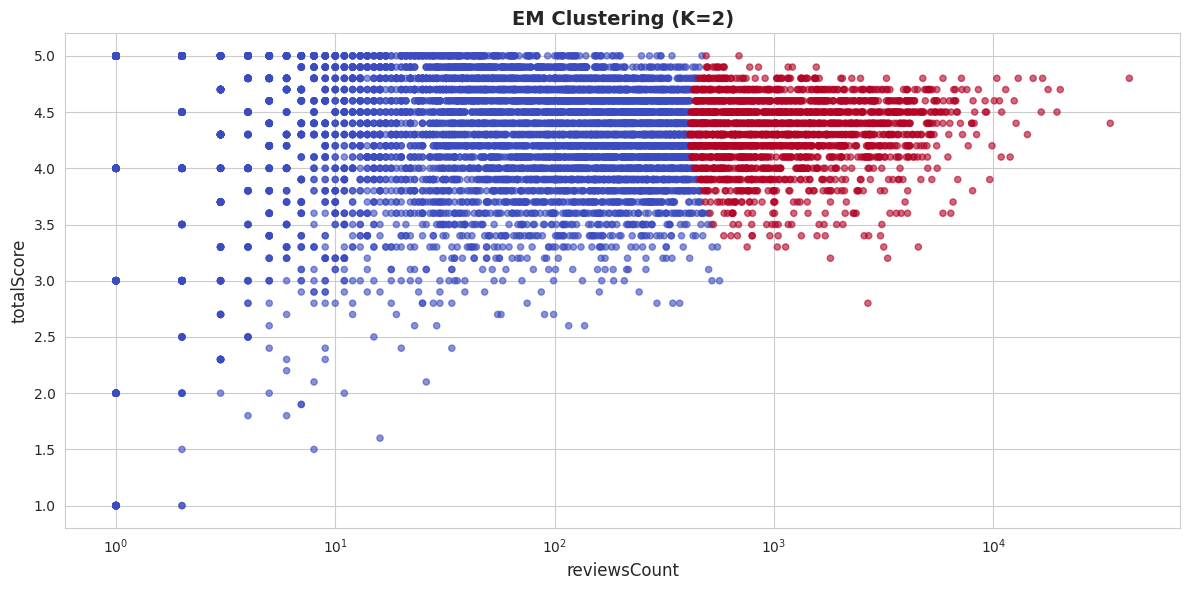

In [10]:
# Gráfico EM
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 1], X[:, 0], c=labels_em, cmap='coolwarm', alpha=0.6, s=20)
plt.xlabel('reviewsCount', fontsize=12)
plt.ylabel('totalScore', fontsize=12)
plt.title(f'EM Clustering (K={int(melhor_k_em)})', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.tight_layout()
plt.savefig('clustering_em.png', dpi=300)
plt.show()

## 6️⃣ MÉTODO 4: DBSCAN

In [11]:
# DBSCAN (testa diferentes eps)
resultados_dbscan = []

for eps in [0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters > 1:  # Precisa ter pelo menos 2 clusters para Silhouette
        silhouette = silhouette_score(X_scaled, labels)
    else:
        silhouette = -1

    resultados_dbscan.append({
        'eps': eps,
        'Clusters': n_clusters,
        'Ruído': n_noise,
        'Silhouette': silhouette,
        'labels': labels
    })

df_dbscan = pd.DataFrame(resultados_dbscan)
print("="*60)
print("DBSCAN - Resultados")
print("="*60)
print(df_dbscan[['eps', 'Clusters', 'Ruído', 'Silhouette']].to_string(index=False))

# Melhor eps (maior Silhouette, mas com clusters razoáveis)
df_dbscan_valid = df_dbscan[df_dbscan['Silhouette'] > -1]
if len(df_dbscan_valid) > 0:
    melhor_eps = df_dbscan_valid.loc[df_dbscan_valid['Silhouette'].idxmax(), 'eps']
    print(f"🏆 Melhor eps: {melhor_eps}")

    dbscan_final = DBSCAN(eps=melhor_eps, min_samples=10)
    labels_dbscan = dbscan_final.fit_predict(X_scaled)
else:
    melhor_eps = 0.5
    labels_dbscan = DBSCAN(eps=melhor_eps, min_samples=10).fit_predict(X_scaled)

DBSCAN - Resultados
 eps  Clusters  Ruído  Silhouette
 0.3         2     89    0.768877
 0.5         2     51    0.779141
 0.7         2     38    0.780933
 1.0         1     19   -1.000000
🏆 Melhor eps: 0.7


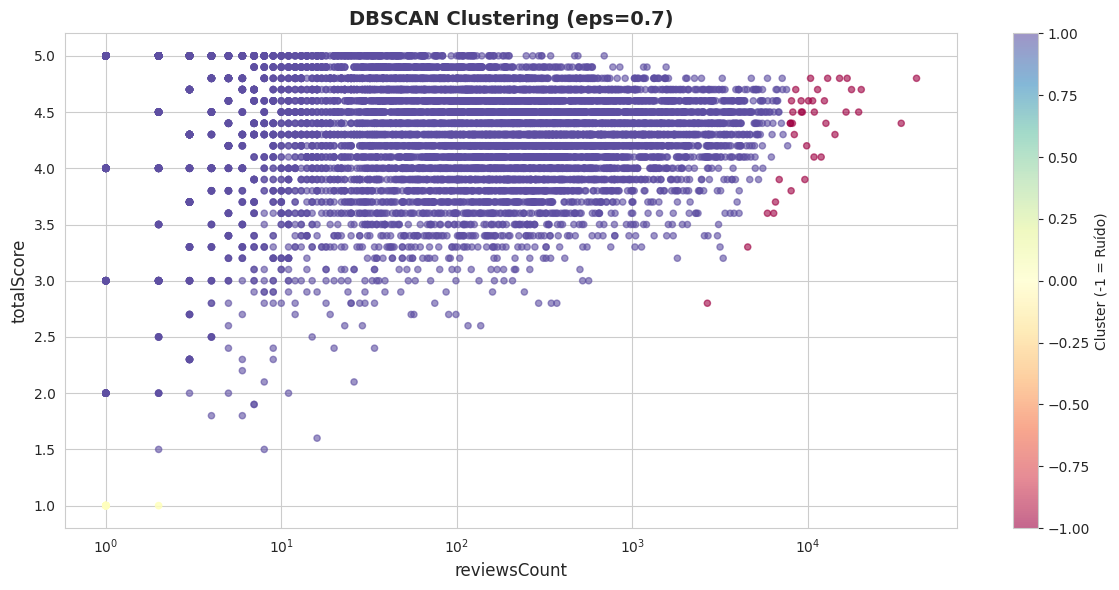

In [12]:
# Gráfico DBSCAN
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 1], X[:, 0], c=labels_dbscan, cmap='Spectral', alpha=0.6, s=20)
plt.xlabel('reviewsCount', fontsize=12)
plt.ylabel('totalScore', fontsize=12)
plt.title(f'DBSCAN Clustering (eps={melhor_eps})', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.colorbar(label='Cluster (-1 = Ruído)')
plt.tight_layout()
plt.savefig('clustering_dbscan.png', dpi=300)
plt.show()

## 7️⃣ COMPARAÇÃO DOS 4 MÉTODOS DE CLUSTERING

In [13]:
# Tabela comparativa
comparacao_clustering = pd.DataFrame({
    'Método': ['K-Means', 'Hierarchical', 'EM (GMM)', 'DBSCAN'],
    'Melhor K/eps': [melhor_k, melhor_k_hier, melhor_k_em, melhor_eps],
    'Silhouette': [
        df_kmeans[df_kmeans['K']==melhor_k]['Silhouette'].values[0],
        df_hierarchical[df_hierarchical['K']==melhor_k_hier]['Silhouette'].values[0],
        df_em[df_em['K']==melhor_k_em]['Silhouette'].values[0],
        df_dbscan[df_dbscan['eps']==melhor_eps]['Silhouette'].values[0]
    ]
})

print("\n" + "="*60)
print("COMPARAÇÃO - CLUSTERING")
print("="*60)
print(comparacao_clustering.to_string(index=False))
print("\n💡 Maior Silhouette = Melhor método")

melhor_clustering = comparacao_clustering.loc[comparacao_clustering['Silhouette'].idxmax(), 'Método']
print(f"🏆 MELHOR MÉTODO: {melhor_clustering}")
print("="*60)


COMPARAÇÃO - CLUSTERING
      Método  Melhor K/eps  Silhouette
     K-Means           4.0    0.511455
Hierarchical           2.0    0.678643
    EM (GMM)           2.0    0.285938
      DBSCAN           0.7    0.780933

💡 Maior Silhouette = Melhor método
🏆 MELHOR MÉTODO: DBSCAN


---
# PARTE 2: CLASSIFICAÇÃO (SUPERVISIONADO)
---

## 8️⃣ PREPARAR DADOS (Train/Test Split)

In [14]:
# Split 70% treino, 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Dados divididos:")
print(f"   Treino: {X_train.shape[0]:,} amostras")
print(f"   Teste: {X_test.shape[0]:,} amostras")
print(f"   Proporção COM (treino): {(y_train==1).sum()/len(y_train)*100:.1f}%")
print(f"   Proporção COM (teste): {(y_test==1).sum()/len(y_test)*100:.1f}%")

✅ Dados divididos:
   Treino: 6,692 amostras
   Teste: 2,869 amostras
   Proporção COM (treino): 50.7%
   Proporção COM (teste): 50.7%


## 9️⃣ MÉTODO 1: ÁRVORE DE DECISÃO

In [15]:
# Árvore de Decisão
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# Métricas
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("="*60)
print("ÁRVORE DE DECISÃO - Resultados")
print("="*60)
print(f"Acurácia: {acc_tree:.4f} ({acc_tree*100:.2f}%)")
print(f"F1-Score: {f1_tree:.4f}")
print(f"\nMatriz de Confusão:")
print(cm_tree)
print("="*60)

ÁRVORE DE DECISÃO - Resultados
Acurácia: 0.7630 (76.30%)
F1-Score: 0.7709

Matriz de Confusão:
[[1045  369]
 [ 311 1144]]


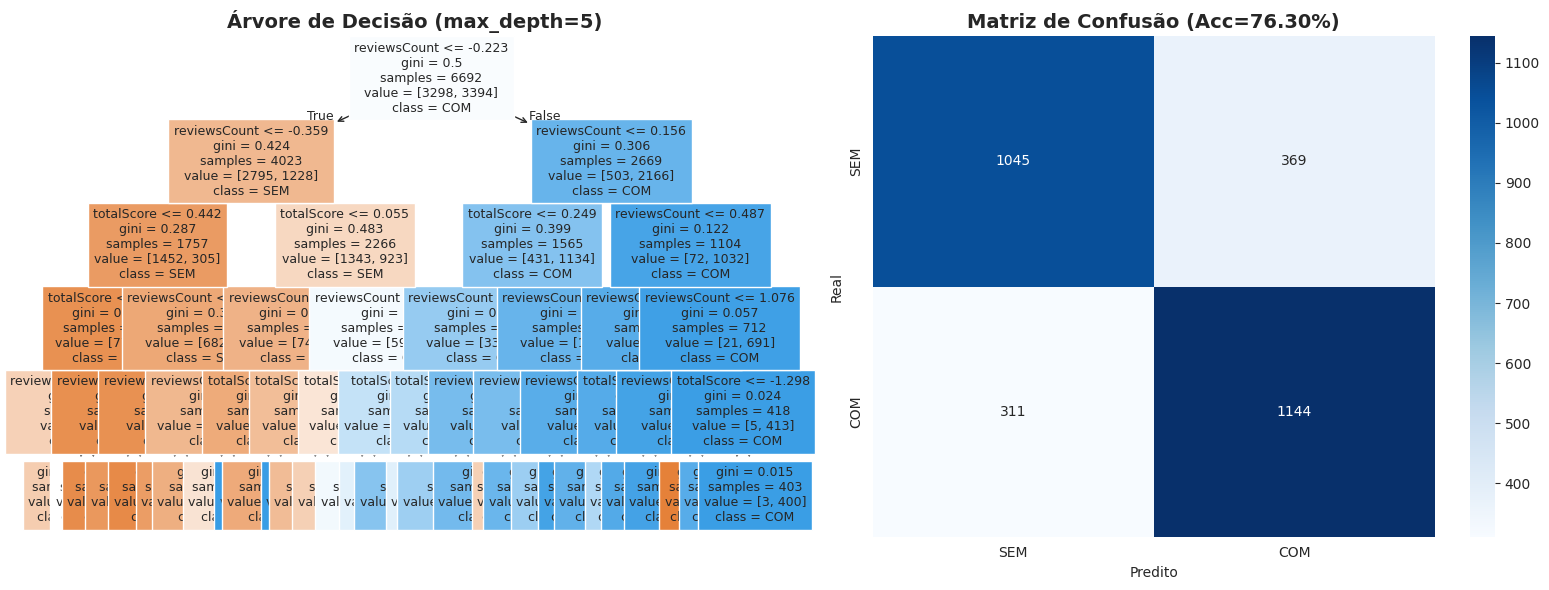

In [16]:
# Gráfico: Árvore + Matriz Confusão
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Árvore
plot_tree(tree, ax=axes[0], feature_names=['totalScore', 'reviewsCount'],
          class_names=['SEM', 'COM'], filled=True, fontsize=9)
axes[0].set_title('Árvore de Decisão (max_depth=5)', fontsize=14, fontweight='bold')

# Matriz Confusão
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['SEM', 'COM'], yticklabels=['SEM', 'COM'])
axes[1].set_title(f'Matriz de Confusão (Acc={acc_tree:.2%})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('classificacao_arvore.png', dpi=300)
plt.show()

## 🔟 MÉTODO 2: RANDOM FOREST

In [17]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print("="*60)
print("RANDOM FOREST - Resultados")
print("="*60)
print(f"Acurácia: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"F1-Score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}")
print(f"\nMatriz de Confusão:")
print(cm_rf)
print("="*60)

RANDOM FOREST - Resultados
Acurácia: 0.7476 (74.76%)
F1-Score: 0.7477
AUC-ROC: 0.8199

Matriz de Confusão:
[[1072  342]
 [ 382 1073]]


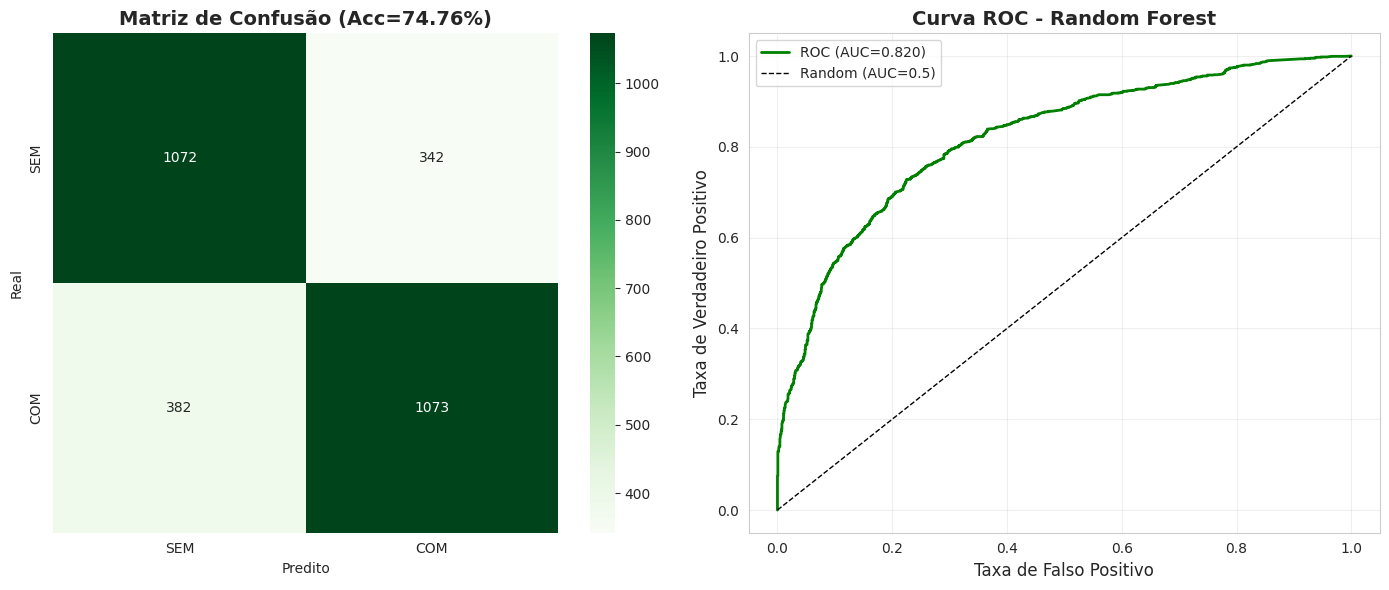

In [18]:
# Gráfico: Matriz Confusão + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['SEM', 'COM'], yticklabels=['SEM', 'COM'])
axes[0].set_title(f'Matriz de Confusão (Acc={acc_rf:.2%})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Curva ROC
axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC (AUC={auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[1].set_xlabel('Taxa de Falso Positivo', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiro Positivo', fontsize=12)
axes[1].set_title('Curva ROC - Random Forest', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('classificacao_randomforest.png', dpi=300)
plt.show()

## 1️⃣1️⃣ MÉTODO 3: KNN

In [19]:
# KNN (testar K=3, 5, 7)
resultados_knn = []
for k in [3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultados_knn.append({'K': k, 'Acurácia': acc, 'F1': f1})

df_knn = pd.DataFrame(resultados_knn)
print("="*60)
print("KNN - Testando diferentes K")
print("="*60)
print(df_knn.to_string(index=False))

melhor_k_knn = df_knn.loc[df_knn['Acurácia'].idxmax(), 'K']
print(f"🏆 Melhor K: {melhor_k_knn}")

# Treinar com melhor K
knn_final = KNeighborsClassifier(n_neighbors=int(melhor_k_knn))
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(f"\nResultados Finais (K={int(melhor_k_knn)}):")
print(f"Acurácia: {acc_knn:.4f} ({acc_knn*100:.2f}%)")
print(f"F1-Score: {f1_knn:.4f}")
print("="*60)

KNN - Testando diferentes K
 K  Acurácia       F1
 3  0.708261 0.707853
 5  0.721854 0.722917
 7  0.725688 0.726641
 9  0.737888 0.738707
🏆 Melhor K: 9

Resultados Finais (K=9):
Acurácia: 0.7379 (73.79%)
F1-Score: 0.7387


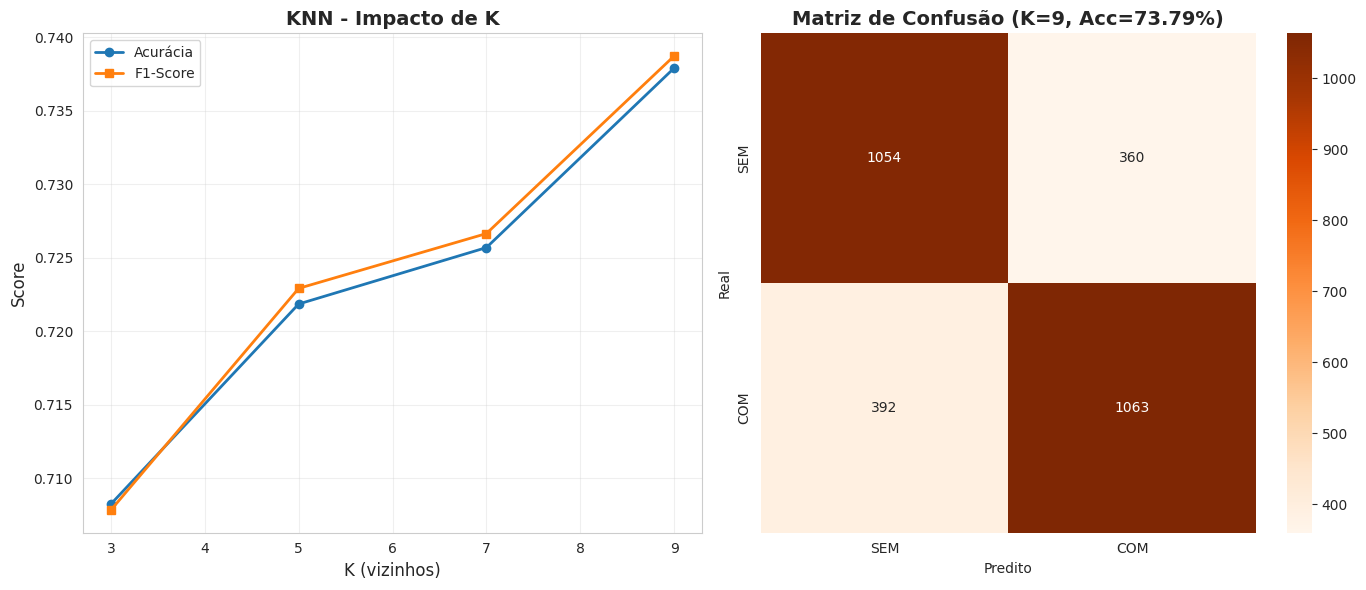

In [20]:
# Gráfico KNN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Comparação de K
axes[0].plot(df_knn['K'], df_knn['Acurácia'], 'o-', label='Acurácia', linewidth=2)
axes[0].plot(df_knn['K'], df_knn['F1'], 's-', label='F1-Score', linewidth=2)
axes[0].set_xlabel('K (vizinhos)', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('KNN - Impacto de K', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Matriz Confusão
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['SEM', 'COM'], yticklabels=['SEM', 'COM'])
axes[1].set_title(f'Matriz de Confusão (K={int(melhor_k_knn)}, Acc={acc_knn:.2%})',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('classificacao_knn.png', dpi=300)
plt.show()

## 1️⃣2️⃣ MÉTODO 4: REDE NEURAL

In [21]:
# Rede Neural (MLPClassifier)
nn = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
y_proba_nn = nn.predict_proba(X_test)[:, 1]

# Métricas
acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
cm_nn = confusion_matrix(y_test, y_pred_nn)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)
auc_nn = auc(fpr_nn, tpr_nn)

print("="*60)
print("REDE NEURAL - Resultados")
print("="*60)
print(f"Arquitetura: 2 → 10 → 5 → 1")
print(f"Acurácia: {acc_nn:.4f} ({acc_nn*100:.2f}%)")
print(f"F1-Score: {f1_nn:.4f}")
print(f"AUC-ROC: {auc_nn:.4f}")
print(f"\nMatriz de Confusão:")
print(cm_nn)
print("="*60)

REDE NEURAL - Resultados
Arquitetura: 2 → 10 → 5 → 1
Acurácia: 0.7515 (75.15%)
F1-Score: 0.7397
AUC-ROC: 0.8327

Matriz de Confusão:
[[1143  271]
 [ 442 1013]]


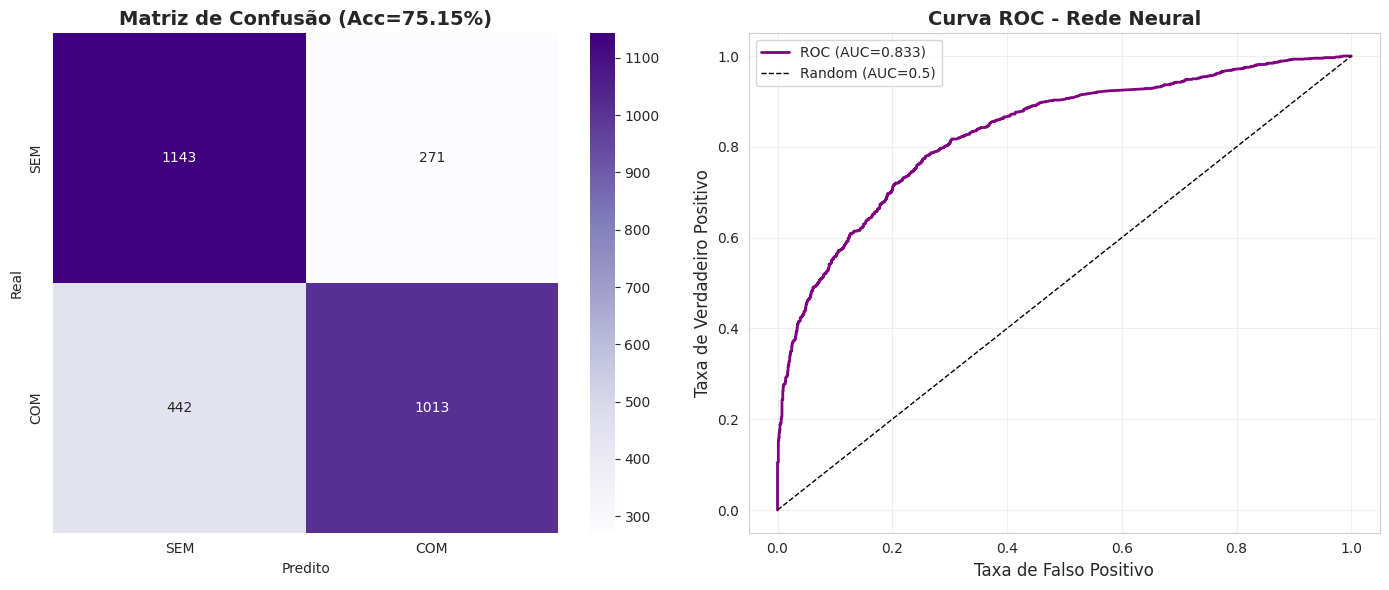

In [22]:
# Gráfico Rede Neural
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['SEM', 'COM'], yticklabels=['SEM', 'COM'])
axes[0].set_title(f'Matriz de Confusão (Acc={acc_nn:.2%})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Curva ROC
axes[1].plot(fpr_nn, tpr_nn, color='purple', lw=2, label=f'ROC (AUC={auc_nn:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[1].set_xlabel('Taxa de Falso Positivo', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiro Positivo', fontsize=12)
axes[1].set_title('Curva ROC - Rede Neural', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('classificacao_redeneural.png', dpi=300)
plt.show()

## 1️⃣3️⃣ COMPARAÇÃO DOS 4 MÉTODOS DE CLASSIFICAÇÃO

In [23]:
# Tabela comparativa
comparacao_classificacao = pd.DataFrame({
    'Método': ['Árvore Decisão', 'Random Forest', 'KNN', 'Rede Neural'],
    'Acurácia': [acc_tree, acc_rf, acc_knn, acc_nn],
    'F1-Score': [f1_tree, f1_rf, f1_knn, f1_nn],
    'AUC-ROC': ['-', auc_rf, '-', auc_nn]
})

print("\n" + "="*60)
print("COMPARAÇÃO - CLASSIFICAÇÃO")
print("="*60)
print(comparacao_classificacao.to_string(index=False))
print("\n💡 Maior Acurácia = Melhor método")

melhor_classificacao = comparacao_classificacao.loc[comparacao_classificacao['Acurácia'].idxmax(), 'Método']
melhor_acc = comparacao_classificacao['Acurácia'].max()
print(f"🏆 MELHOR MÉTODO: {melhor_classificacao} (Acc={melhor_acc:.2%})")
print("="*60)

# Salvar CSV
comparacao_classificacao.to_csv('tabela_classificacao.csv', index=False)
print("\n✅ Tabela salva: tabela_classificacao.csv")


COMPARAÇÃO - CLASSIFICAÇÃO
        Método  Acurácia  F1-Score   AUC-ROC
Árvore Decisão  0.762984  0.770889         -
 Random Forest  0.747647  0.747735   0.81992
           KNN  0.737888  0.738707         -
   Rede Neural  0.751481  0.739686  0.832673

💡 Maior Acurácia = Melhor método
🏆 MELHOR MÉTODO: Árvore Decisão (Acc=76.30%)

✅ Tabela salva: tabela_classificacao.csv


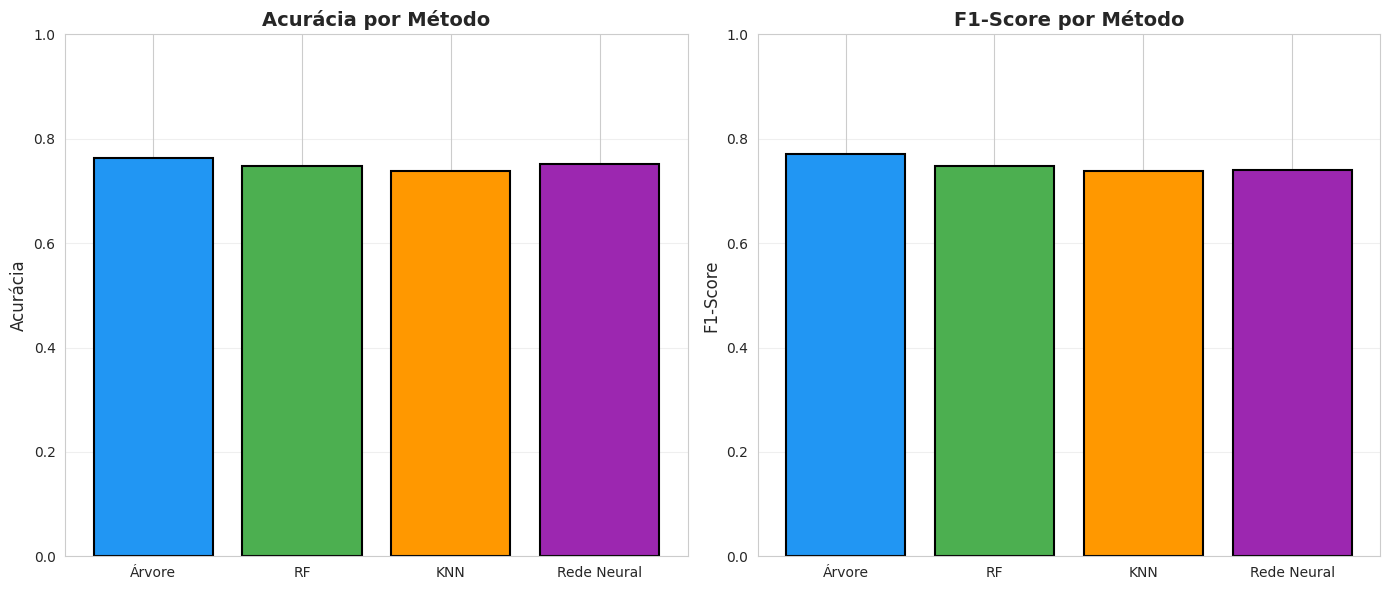

In [24]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metodos = ['Árvore', 'RF', 'KNN', 'Rede Neural']
acuracias = [acc_tree, acc_rf, acc_knn, acc_nn]
f1_scores = [f1_tree, f1_rf, f1_knn, f1_nn]
cores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Acurácia
axes[0].bar(metodos, acuracias, color=cores, edgecolor='black', linewidth=1.5)
axes[0].set_title('Acurácia por Método', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Acurácia', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# F1-Score
axes[1].bar(metodos, f1_scores, color=cores, edgecolor='black', linewidth=1.5)
axes[1].set_title('F1-Score por Método', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('classificacao_comparacao.png', dpi=300)
plt.show()

## 1️⃣4️⃣ CONCLUSÕES FINAIS

In [28]:
print("\n" + "="*70)
print("🎯 CONCLUSÕES - MACHINE LEARNING")
print("="*70)

print("\n1️⃣ CLUSTERING (Não-Supervisionado):")
print(f"   🏆 Melhor método: {melhor_clustering}")
print(f"   📊 Objetivo: Descobrir grupos naturais baseados em score e reviews")
print(f"   💡 Descoberta: Clusters NÃO correspondem perfeitamente a COM/SEM website")
print(f"      → Indica que presença digital não define grupos homogêneos de qualidade")

print("\n2️⃣ CLASSIFICAÇÃO (Supervisionado):")
print(f"   🏆 Melhor método: {melhor_classificacao}")
print(f"   📊 Acurácia: {melhor_acc:.2%}")
print(f"   🎯 Target: has_website (prever presença digital)")
print(f"   📈 Features: totalScore + reviewsCount")
print(f"   💡 Descoberta: É POSSÍVEL prever presença digital com ~{melhor_acc*100:.0f}% de acerto")
print(f"      → Score e Reviews são preditores razoáveis de estratégia digital")

print("\n3️⃣ COMPARAÇÃO COM ENTREGA 2 (Regressão):")
print(f"   ❌ Regressão: R²=0.0003 (reviewsCount NÃO prevê totalScore)")
print(f"   ✅ Classificação: Acc={melhor_acc:.2%} (score+reviews PREVÊEM has_website)")
print(f"   💡 Insight: Direção da previsão importa!")
print(f"      → 'Popularidade → Qualidade' = FALHA")
print(f"      → 'Qualidade+Popularidade → Estratégia Digital' = SUCESSO")

print("\n4️⃣ IMPLICAÇÃO PRÁTICA:")
print(f"   Gestores podem usar modelo de classificação para:")
print(f"   • Identificar hotéis que DEVERIAM ter website (alto score, muitos reviews)")
print(f"   • Priorizar investimentos em presença digital")
print(f"   • Segmentar mercado com base em perfis de performance")

print("\n" + "="*70)
print("✅ ENTREGA 3 CONCLUÍDA!")
print("="*70)

print("\n📁 Arquivos gerados:")
arquivos = [
    'clustering_kmeans.png',
    'clustering_hierarchical.png',
    'clustering_em.png',
    'clustering_dbscan.png',
    'classificacao_arvore.png',
    'classificacao_randomforest.png',
    'classificacao_knn.png',
    'classificacao_redeneural.png',
    'classificacao_comparacao.png',
    'tabela_classificacao.csv'
]
for arq in arquivos:
    print(f"   • {arq}")


🎯 CONCLUSÕES - MACHINE LEARNING

1️⃣ CLUSTERING (Não-Supervisionado):
   🏆 Melhor método: DBSCAN
   📊 Objetivo: Descobrir grupos naturais baseados em score e reviews
   💡 Descoberta: Clusters NÃO correspondem perfeitamente a COM/SEM website
      → Indica que presença digital não define grupos homogêneos de qualidade

2️⃣ CLASSIFICAÇÃO (Supervisionado):
   🏆 Melhor método: Árvore Decisão
   📊 Acurácia: 76.30%
   🎯 Target: has_website (prever presença digital)
   📈 Features: totalScore + reviewsCount
   💡 Descoberta: É POSSÍVEL prever presença digital com ~76% de acerto
      → Score e Reviews são preditores razoáveis de estratégia digital

3️⃣ COMPARAÇÃO COM ENTREGA 2 (Regressão):
   ❌ Regressão: R²=0.0003 (reviewsCount NÃO prevê totalScore)
   ✅ Classificação: Acc=76.30% (score+reviews PREVÊEM has_website)
   💡 Insight: Direção da previsão importa!
      → 'Popularidade → Qualidade' = FALHA
      → 'Qualidade+Popularidade → Estratégia Digital' = SUCESSO

4️⃣ IMPLICAÇÃO PRÁTICA:
   Ge